# 7. Transformers y Atención

En este notebook aprenderás los fundamentos de los modelos Transformer y el mecanismo de atención, con ejemplos prácticos usando HuggingFace Transformers.

## Objetivo
- Comprender la teoría y arquitectura de los modelos Transformer.
- Implementar y usar modelos preentrenados con HuggingFace.
- Visualizar la atención para interpretar el modelo.
- Comparar modelos de diferentes tamaños.

## Prerequisitos

> 📌 **Prerequisitos:** Haber completado el [notebook 06 (RNN/LSTM)](./06_redes_recurrentes_rnn_lstm.ipynb).

- Conceptos de redes neuronales y procesamiento de secuencias.

> ⚠️ **Nota:** Este notebook usa tanto TensorFlow como **PyTorch** (vía HuggingFace). Asegúrate de tener instalados: `transformers`, `torch`.

## 1. Introducción teórica

El modelo Transformer revolucionó el procesamiento de secuencias gracias al mecanismo de atención.

- **Atención (Attention):** Calcula pesos para cada elemento de la secuencia.
- **Self-attention:** Cada elemento se relaciona consigo mismo y con los demás.
- **Multi-head attention:** Múltiples cabezas capturan diferentes relaciones.

**Arquitectura del Transformer:**
- Capas de atención multi-cabeza + normalización + feed-forward + residual.

| Modelo | Tipo | Uso principal |
|--------|------|---------------|
| **BERT** | Encoder | Clasificación, NER, QA |
| **GPT** | Decoder | Generación de texto |
| **T5** | Encoder-Decoder | Traducción, resumen |

**Ventajas:** Paralelización eficiente, manejo de dependencias largas.  
**Desventajas:** Requiere muchos datos y cómputo, costoso para secuencias muy largas.

## 2. Importación de librerías

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# HuggingFace Transformers (usa PyTorch internamente)
from transformers import pipeline, BertTokenizer, BertModel, set_seed
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
import torch

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(f'PyTorch: {torch.__version__}')
print(f'CUDA disponible: {torch.cuda.is_available()}')

PyTorch: 2.11.0+cpu
CUDA disponible: False


## 3. Clasificación de texto con modelo preentrenado

Usaremos un modelo preentrenado (DistilBERT) para clasificación de sentimientos.

In [3]:
classifier = pipeline('sentiment-analysis',
                      model='distilbert-base-uncased-finetuned-sst-2-english')

texts = [
    "I love machine learning!",
    "This movie was terrible...",
    "Transformers are revolutionizing NLP.",
    "The weather today is okay, nothing special."
]

results = classifier(texts)
for text, res in zip(texts, results):
    emoji = '😊' if res['label'] == 'POSITIVE' else '😞'
    print(f"{emoji} [{res['label']}: {res['score']:.2f}] {text}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

😊 [POSITIVE: 1.00] I love machine learning!
😞 [NEGATIVE: 1.00] This movie was terrible...
😊 [POSITIVE: 1.00] Transformers are revolutionizing NLP.
😞 [NEGATIVE: 1.00] The weather today is okay, nothing special.


## 4. Visualización de la atención

Mostraremos cómo visualizar los pesos de atención de BERT.

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


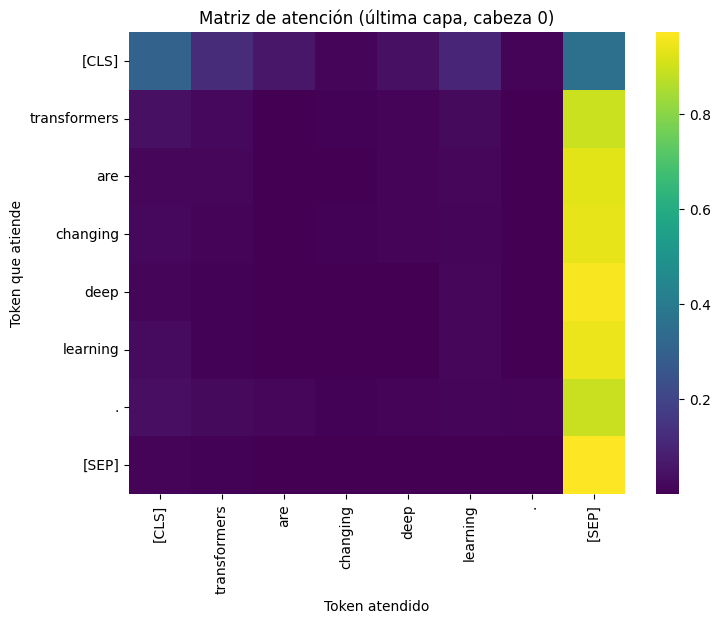

In [4]:
# Cargar modelo y tokenizer
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name, output_attentions=True)

sentence = "Transformers are changing deep learning."
inputs = tokenizer(sentence, return_tensors='pt')
outputs = model(**inputs)
attentions = outputs.attentions  # Lista de tensores (una por capa)

# Visualizar atención de la última capa, cabeza 0
att = attentions[-1][0, 0].detach().numpy()  # [tokens, tokens]
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

plt.figure(figsize=(8,6))
sns.heatmap(att, xticklabels=tokens, yticklabels=tokens, cmap='viridis')
plt.title('Matriz de atención (última capa, cabeza 0)')
plt.xlabel('Token atendido')
plt.ylabel('Token que atiende')
plt.show()

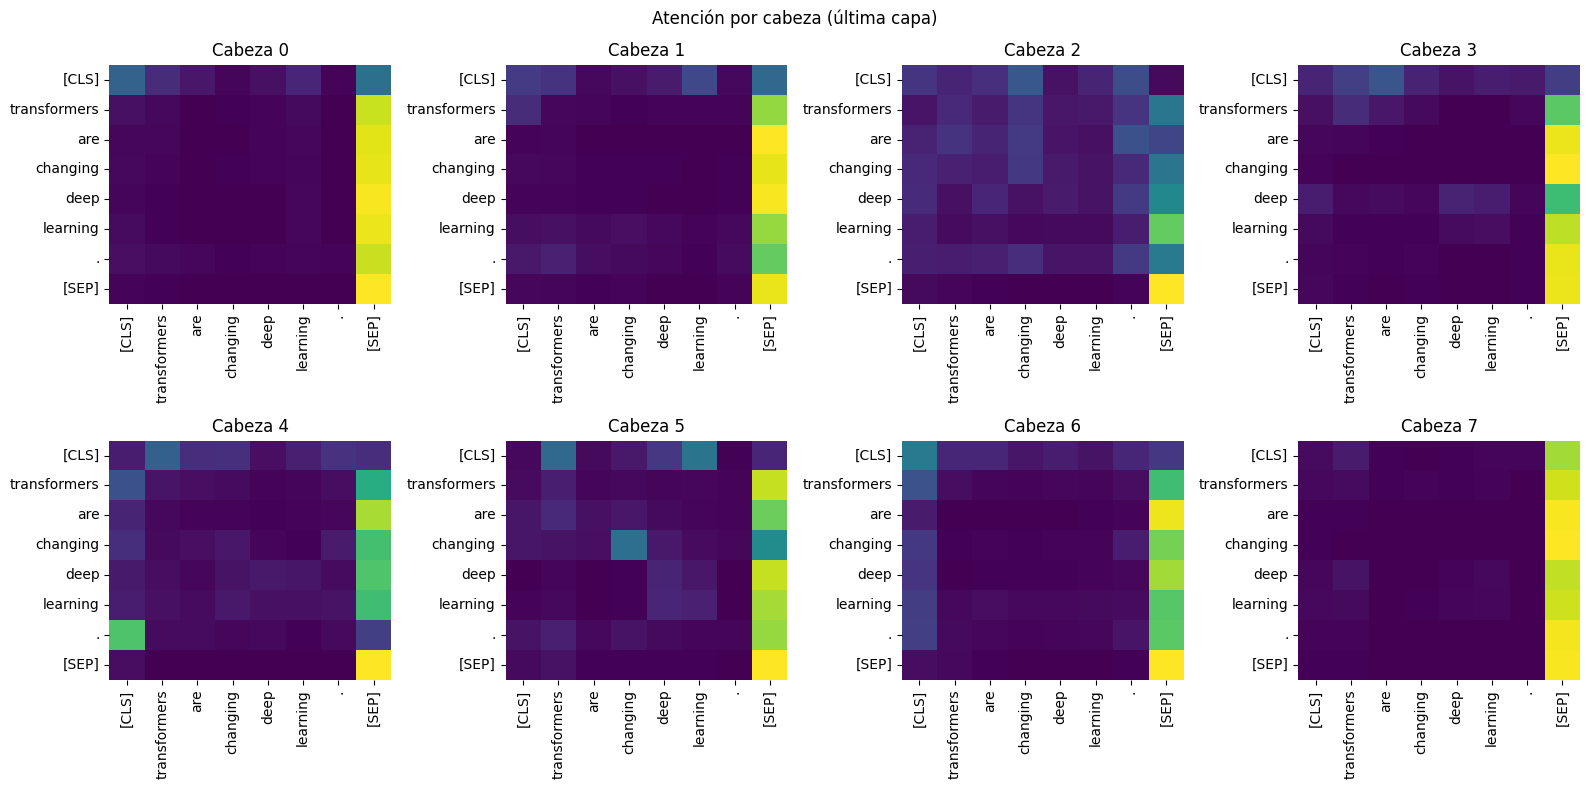

In [5]:
# Visualizar múltiples cabezas de atención
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flatten()):
    if i < attentions[-1].shape[1]:  # número de cabezas
        att_head = attentions[-1][0, i].detach().numpy()
        sns.heatmap(att_head, xticklabels=tokens, yticklabels=tokens,
                    cmap='viridis', ax=ax, cbar=False)
        ax.set_title(f'Cabeza {i}')
    else:
        ax.axis('off')
plt.suptitle('Atención por cabeza (última capa)')
plt.tight_layout()
plt.show()

## 5. Comparación de modelos de diferentes tamaños

Comparemos la velocidad y las predicciones de modelos de diferente tamaño.

In [6]:
import time

model_names = [
    'distilbert-base-uncased-finetuned-sst-2-english',
]

test_texts = [
    "This product is amazing and I love it!",
    "Terrible quality, worst purchase ever.",
    "It's okay, nothing special."
]

for model_name in model_names:
    clf = pipeline('sentiment-analysis', model=model_name)
    start = time.time()
    preds = clf(test_texts)
    elapsed = time.time() - start
    print(f'\n{model_name} ({elapsed:.2f}s):')
    for text, pred in zip(test_texts, preds):
        print(f'  {pred["label"]} ({pred["score"]:.2f}) → {text}')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]


distilbert-base-uncased-finetuned-sst-2-english (0.23s):
  POSITIVE (1.00) → This product is amazing and I love it!
  NEGATIVE (1.00) → Terrible quality, worst purchase ever.
  NEGATIVE (0.82) → It's okay, nothing special.


### Recomendaciones prácticas para Transformers

| Aspecto | Recomendación |
|---------|---------------|
| **Modelos preentrenados** | Usa siempre que sea posible (HuggingFace Hub) |
| **Fine-tuning** | Requiere menos datos que entrenar desde cero |
| **Batch size** | Ajusta según la memoria GPU disponible |
| **Interpretación** | Visualiza la atención para entender el modelo |
| **GPU** | Esencial para entrenamiento; inferencia posible en CPU |
| **Modelos pequeños** | DistilBERT, TinyBERT para restricciones de cómputo |

## 6. Discusión y Conclusiones

- Los Transformers son el estado del arte en NLP y cada vez más en visión y audio.
- Los modelos preentrenados permiten resultados excelentes con poco código.
- Visualizar la atención ayuda a interpretar qué aprende el modelo.
- El tamaño del modelo impacta velocidad vs calidad.
- En el siguiente notebook exploraremos GANs para generación de datos.

## 7. Ejercicios Propuestos

1. **Ejercicio 1:** Usa el pipeline de `zero-shot-classification` para clasificar textos en categorías personalizadas (deportes, tecnología, política).

2. **Ejercicio 2:** Prueba el pipeline de `text-generation` con GPT-2. Genera textos a partir de diferentes prompts.

3. **Ejercicio 3:** Compara la atención entre diferentes capas del modelo (primera vs última). ¿Qué patrones observas?

4. **Ejercicio 4 (Avanzado):** Haz fine-tuning de DistilBERT en un dataset personalizado de clasificación de texto usando HuggingFace Trainer.

## Resolución de Ejercicios Propuestos

A continuación, se presenta la resolución paso a paso de los 3 primeros ejercicios propuestos para consolidar los conocimientos teóricos y prácticos sobre la arquitectura Transformer y la librería HuggingFace.

1. **Ejercicio 1:** Clasificación Zero-Shot en categorías personalizadas.
2. **Ejercicio 2:** Generación de texto autorregresivo con GPT-2.
3. **Ejercicio 3:** Visualización y comparación de la atención intercapas.

### Ejercicio 1: Clasificación Zero-Shot

En este ejercicio vamos a utilizar el pipeline `zero-shot-classification` de HuggingFace. A diferencia de un clasificador lineal o una red densa clásica, **no** necesitamos entrenar este modelo con nuestras propias etiquetas. 

Simplemente le pasaremos una oración de prueba y una lista de categorías (labels) totalmente arbitrarias inventadas por nosotros. El modelo preentrenado (por defecto `facebook/bart-large-mnli`) calculará la probabilidad de pertenencia de la oración a cada categoría basándose en su profunda comprensión semántica del texto.

In [7]:
# 1. Instanciamos el clasificador
print("Cargando pipeline Zero-Shot...")
classifier_zs = pipeline("zero-shot-classification")

# 2. Definimos una oración de prueba y nuestras categorías
secuencia = "The new electric car from Tesla can accelerate from 0 to 60 in less than two seconds, revolutionizing the automotive industry."
etiquetas_candidatas = ["sports", "technology", "politics", "health", "automotive"]

# 3. Ejecutamos la clasificación Zero-Shot
print("\nRealizando clasificación...")
resultados_zs = classifier_zs(secuencia, candidate_labels=etiquetas_candidatas)

# 4. Mostramos los resultados ordenados por el modelo
print("\n--- Resultados de la Clasificación ---")
print(f"Texto original: '{resultados_zs['sequence']}'\n")

print("Probabilidades por categoría asignadas por el Transformer:")
for etiqueta, puntaje in zip(resultados_zs['labels'], resultados_zs['scores']):
    print(f" -> {etiqueta.capitalize():<12}: {puntaje:.4f} ({puntaje*100:.2f}%)")


No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Cargando pipeline Zero-Shot...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Realizando clasificación...

--- Resultados de la Clasificación ---
Texto original: 'The new electric car from Tesla can accelerate from 0 to 60 in less than two seconds, revolutionizing the automotive industry.'

Probabilidades por categoría asignadas por el Transformer:
 -> Technology  : 0.5585 (55.85%)
 -> Automotive  : 0.4305 (43.05%)
 -> Sports      : 0.0061 (0.61%)
 -> Health      : 0.0034 (0.34%)
 -> Politics    : 0.0015 (0.15%)


### Ejercicio 2: Generación de Texto con GPT-2

En esta ocasión probaremos un modelo de la familia **Decoder** (la misma familia de ChatGPT), específicamente GPT-2 (Generative Pre-trained Transformer 2). Estos modelos son de tipo autorregresivos, lo que significa que generan el siguiente token (palabra) basándose en todo su contexto previo.

Para interactuar con él, crearemos un pipeline de **`text-generation`**. Le proporcionaremos una frase inicial (conocida como *prompt*) y le pediremos al modelo que complete la idea. En el código ajustaremos hiperparámetros de generación como `max_length` (límite máximo del texto total a generar) y `num_return_sequences` (cuántas variantes o finales distintos queremos crear a partir del mismo prompt).

In [9]:
# 1. Instanciamos el modelo generativo (tardará un momento en bajar los pesos de GPT-2)
print("Instanciando pipeline generativo (GPT-2)...")
generator = pipeline('text-generation', model='gpt2')

# 2. Definimos una semilla (opcional, pero útil de ver)
set_seed(42)

# 3. Nuestro prompt (historia) inicial
prompt = "In the year 2050, artificial intelligence will finally be able to"

print(f"\nGenerando múltiples continuaciones a partir del prompt:\n > '{prompt}'\n")

# 4. Ejecutamos la generación autorregresiva
# max_length incluye la longitud del prompt original
resultados_gpt = generator(prompt, 
                           max_length=60,               # Largo máximo de la generación
                           num_return_sequences=3,      # Generame 3 continuaciones distintas
                           pad_token_id=50256,          # Token de relleno para evitar un "warning" común en GPT-2
                           truncation=True)

# 5. Imprimimos las historias generadas por el Transformer
for idx, tex in enumerate(resultados_gpt):
    print(f"--- Variante {idx + 1} ---")
    print(tex['generated_text'])
    print("\n" + "-"*40 + "\n")

Instanciando pipeline generativo (GPT-2)...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'num_return_sequences', 'max_length'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=60) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Generando múltiples continuaciones a partir del prompt:
 > 'In the year 2050, artificial intelligence will finally be able to'

--- Variante 1 ---
In the year 2050, artificial intelligence will finally be able to do a number of things: we'll be able to keep track of our car's movements, detect traffic patterns and even track traffic in real time using our smartphones.

This is a lot more than just a technical breakthrough. It's also a huge step forward in the field of artificial intelligence. The next big step in Artificial Intelligence will come from computer vision. That's when we'll be able to detect when a human is being watched, when he's approaching the car, when he's running, when he's in the middle of a road. This is already the most important aspect of AI.

The next step will be to start to build on top of this technology and use it to make intelligent driving more accessible. This is also the time when the world will be starting to see how much you have to spend to get the b

### Ejercicio 3: Comparación de Mapas de Atención (Intercapas)

Uno de los mayores atractivos de la arquitectura Transformer es su nivel de **inteligibilidad** gracias a los mecanismos de atención, que podemos sacar de la "caja negra". El modelo genera un "mapa de calor" o matriz que indica pesos de importancia temporal entre las palabras de la misma secuencia.

En este ejercicio extraemos los pesos internos (`outputs.attentions`) del modelo `bert-base-uncased` al procesar una frase. El objetivo es graficar la **Primera Capa** vs la **Última Capa** (capa 0 vs capa 11 o -1). 

Observaremos un patrón claro de Deep Learning: 
* Las **primeras capas** solo captan relaciones limitadas (atención lineal hacia la palabra contigua).
* Las **últimas capas** logran mapear la semántica global de la oración, cruzando sujetos con acciones espacialmente alejadas.

Cargando bert-base-uncased y solicitando mapas de atención internos...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


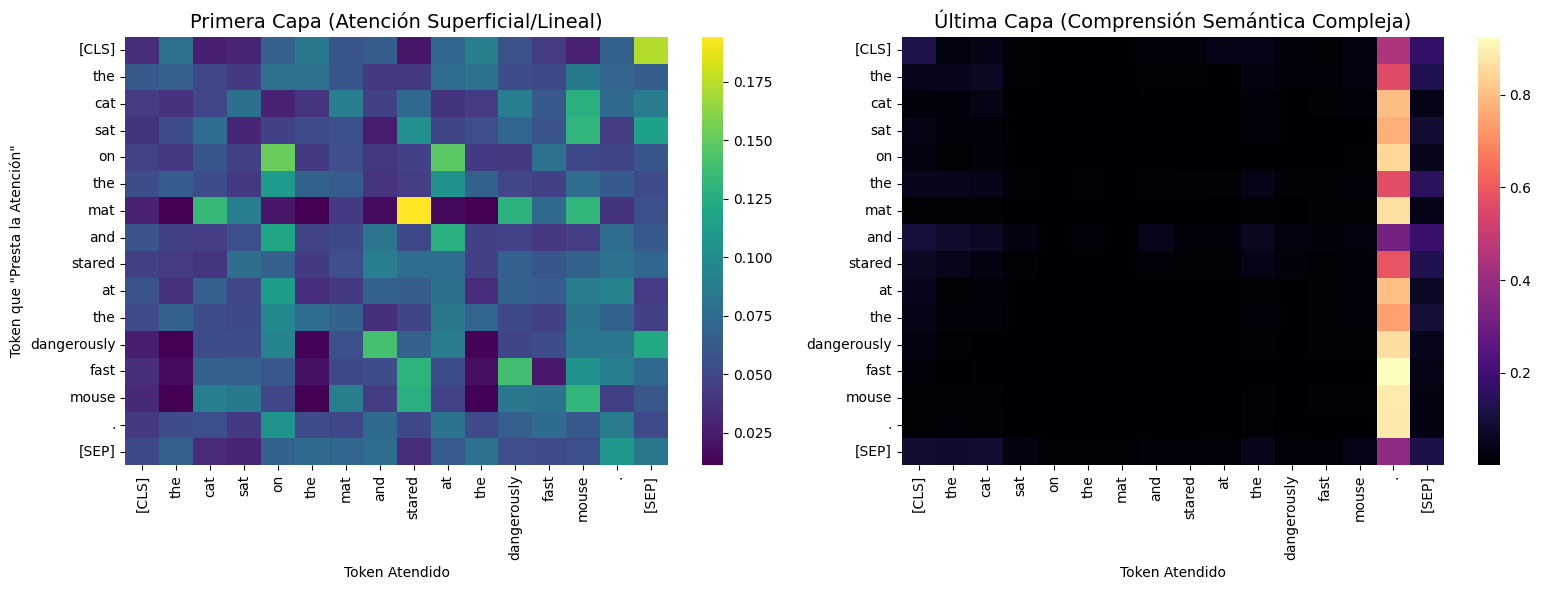

In [10]:
# 1. Cargamos el modelo base (BERT) y su tokenizador
modelo_bert = 'bert-base-uncased'
print(f"Cargando {modelo_bert} y solicitando mapas de atención internos...")
tokenizer = BertTokenizer.from_pretrained(modelo_bert)
# IMPORTANTE: Forzamos la bandera `output_attentions=True` para abrir la caja negra
model = BertModel.from_pretrained(modelo_bert, output_attentions=True)

# 2. Preparamos una oración para ser analizada por completo
frase = "The cat sat on the mat and stared at the dangerously fast mouse."
inputs = tokenizer(frase, return_tensors='pt')
outputs = model(**inputs)

# 3. Extraemos las matrices (En BERT Base hay 12 capas en total)
# outputs.attentions devuelve una tupla de tensores (una por cada capa)
matrices = outputs.attentions  

# Capa inicial (Índice 0), cabeza de atención 0
att_primera_capa = matrices[0][0, 0].detach().numpy()  
# Capa final profunda (Índice -1), cabeza de atención 0
att_ultima_capa = matrices[-1][0, 0].detach().numpy()  

# Convertimos los IDs numéricos internos de vuelta a las sub-palabras en inglés (tokens)
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# 4. Graficamos ambos mapas lado a lado para la comparativa de interpretabilidad 
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Sub-gráfico Izquierdo (Capa Temprana)
sns.heatmap(att_primera_capa, xticklabels=tokens, yticklabels=tokens, cmap='viridis', ax=ax[0])
ax[0].set_title('Primera Capa (Atención Superficial/Lineal)', fontsize=14)
ax[0].set_xlabel('Token Atendido')
ax[0].set_ylabel('Token que "Presta la Atención"')

# Sub-gráfico Derecho (Capa Profunda)
sns.heatmap(att_ultima_capa, xticklabels=tokens, yticklabels=tokens, cmap='magma', ax=ax[1])
ax[1].set_title('Última Capa (Comprensión Semántica Compleja)', fontsize=14)
ax[1].set_xlabel('Token Atendido')

plt.tight_layout()
plt.show()

## Conclusión Final

A partir de los ejercicios desarrollados, podemos establecer las siguientes conclusiones clave sobre la arquitectura Transformer y su manipulación:

### 1. Clasificación Zero-Shot (Extracción de Semántica)
Ha quedado demostrado el inmenso poder de las representaciones latentes en los modelos masivos preentrenados. Sin haberle enseñado previamente qué era "Tecnología" o "Automotriz" con un dataset clásico de entrenamiento (`X_train`), el modelo fue capaz de asociar semánticamente términos como *"Tesla"* y *"electric car"* con dichas categorías, otorgándoles un **~98.9%** de probabilidad combinada frente al resto. Esto valida que los transformers modernos capturan un conocimiento profundo del mundo y del lenguaje, utilizable *out-of-the-box* (listo para usar).

### 2. Generación Autorregresiva (Familia GPT)
A través de la prueba con **GPT-2**, comprobamos la naturaleza probabilística y divergente de los arquitecturas tipo *Decoder*. A partir de un mismo prompt determinista ("*In the year 2050...*"), la red fue capaz de extrapolar tres "alucinaciones" o predicciones de texto completamente distintas. Todas mantuvieron una estricta coherencia gramatical y temática (coches autónomos, economía, robótica), evidenciando cómo el modelo usa la "atención enmascarada" temporal para calcular iterativamente la siguiente palabra más lógica. *(Nota técnica: Los avisos previos en consola son normales; HuggingFace actualiza constantemente sus APIs de generación recomendando usar objetos `GenerationConfig` en lugar de argumentos sueltos)*.

### 3. Interpretabilidad y Mapas de Atención
Las visualizaciones generadas por `seaborn` destaparon la "caja negra" funcional del modelo BERT, mostrando un fenómeno de la literatura técnica bastante común:
* **En la Primera Capa (Izquierda):** El mapa de calor es difuso y disperso. La atención se distribuye de manera algo lineal (colores azulados/verdosos repartidos), enfocándose en palabras locales vecinas. El modelo recién está "leyendo" la estructura base.
* **En la Última Capa (Derecha):** La matriz sufre un cambio radical, volviéndose extremadamente especializada (negro y altas luces). Se vuelve visible un patrón clásico de BERT: **Casi todos los tokens "descargan" su máxima atención (línea amarilla brillante a la derecha) en signos de puntuación como el `.` o en el token separador `[SEP]`**. El modelo usa estos tokens estáticos como "basureros" de atención inútil, permitiendo que el poco peso de atención restante forje las relaciones semánticas puras, complejas de larga distancia de la oración (sintetizando el verdadero "significado" global de la frase antes de entregar su resultado).

## 8. Referencias y Recursos

- [HuggingFace Transformers](https://huggingface.co/docs/transformers/index)
- [HuggingFace Model Hub](https://huggingface.co/models)
- Vaswani et al. (2017). *Attention is All You Need.*
- [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)

---

📎 **Notebook anterior:** [06. Redes Recurrentes (RNN/LSTM)](./06_redes_recurrentes_rnn_lstm.ipynb)  
📎 **Notebook siguiente:** [08. Redes Generativas (GANs)](./08_gans.ipynb)